# EDA - TELCO Customer Churn

In [1]:
import pandas as pd

In [2]:
path = '../data/raw/telco_customer_churn.csv'

In [3]:
df = pd.read_csv(path, sep=';')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         7043 non-null   object
 1   Count              7043 non-null   int64 
 2   Country            7043 non-null   object
 3   State              7043 non-null   object
 4   City               7043 non-null   object
 5   Zip Code           7043 non-null   int64 
 6   Lat Long           7043 non-null   object
 7   Latitude           7043 non-null   object
 8   Longitude          7043 non-null   object
 9   Gender             7043 non-null   object
 10  Senior Citizen     7043 non-null   object
 11  Partner            7043 non-null   object
 12  Dependents         7043 non-null   object
 13  Tenure Months      7043 non-null   int64 
 14  Phone Service      7043 non-null   object
 15  Multiple Lines     7043 non-null   object
 16  Internet Service   7043 non-null   object


In [5]:
df.describe()

,Count,Zip Code,Tenure Months,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,32.371149,0.265370,58.699418,4400.295755
std,0.0,1865.794555,24.559481,0.441561,21.525131,1183.057152
min,1.0,90001.000000,0.000000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,9.000000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,29.000000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,55.000000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,72.000000,1.000000,100.000000,6500.000000


In [6]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783","33,964131","-118,272783",Male,...,Month-to-month,Yes,Mailed check,"53,85","108,15",Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742","34,059281","-118,307420",Female,...,Month-to-month,Yes,Electronic check,"70,7","151,65",Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953","34,048013","-118,293953",Female,...,Month-to-month,Yes,Electronic check,"99,65","820,5",Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709","34,062125","-118,315709",Female,...,Month-to-month,Yes,Electronic check,"104,8","3046,05",Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293","34,039224","-118,266293",Male,...,Month-to-month,Yes,Bank transfer (automatic),"103,7","5036,3",Yes,1,89,5340,Competitor had better devices


### Cria um dataframe para detalhar os missing values em cada coluna

In [7]:
missing_values = pd.DataFrame({
    'columns': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_percentage': (df.isnull().sum() * 100 / len(df)).round(2)
})

missing_values = missing_values[missing_values['missing_count'] > 0].sort_values(by='missing_count', ascending=False)

print(missing_values)

                   columns  missing_count  missing_percentage
Churn Reason  Churn Reason           5174               73.46


In [8]:
df.rename(columns={'Churn Value': 'target'}, inplace=True)
df['target'].unique()

array([1, 0])

In [9]:
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True) * 100
print(target_counts, target_percentages)

target
0    5174
1    1869
Name: count, dtype: int64 target
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [10]:
ratio = target_counts.min() / target_counts.max()
f'{target_counts.min()} / {target_counts.max()} = {ratio:.2f}'

if(ratio == 0.5):
    print(f'O dataset está balanceado. \n{target_counts.min()} / {target_counts.max()} = {ratio:.2f}')
elif(ratio <= 0.7 and ratio >= 0.3):
    print(f'O dataset está levemente desbalanceado. \n{target_counts.min()} / {target_counts.max()} = {ratio:.2f}')
elif(ratio < 0.3 and ratio >= 0.1):
    print(f'O dataset está moderadamente desbalanceado. \n{target_counts.min()} / {target_counts.max()} = {ratio:.2f}')   
else:    
    print(f'O dataset está fortemente desbalanceado. \n{target_counts.min()} / {target_counts.max()} = {ratio:.2f}')

O dataset está levemente desbalanceado. 
1869 / 5174 = 0.36


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


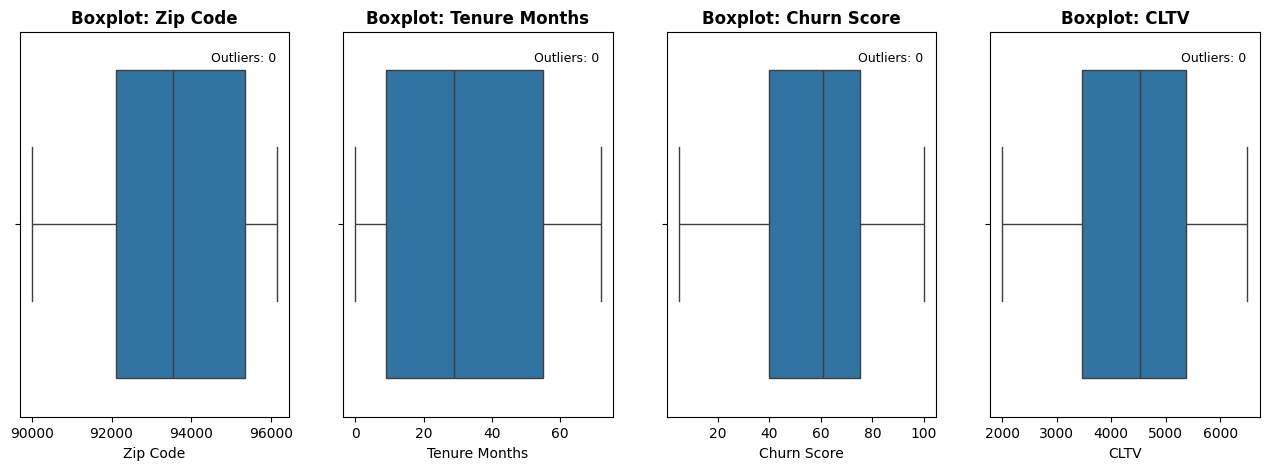

In [12]:
# Colunas numéricas (excluindo target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols_without_target = numeric_cols.drop(['target', 'Count'])

bx_plt_cols = 4
bx_plt_rows = int(np.ceil(len(numeric_cols_without_target) / bx_plt_cols))

fig, axes = plt.subplots(bx_plt_rows, bx_plt_cols, figsize=(16, 5 * bx_plt_rows))
axes = axes.ravel()

for i, col in enumerate(numeric_cols_without_target):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')


    # O desvio padrão mede o quanto os dados estão espalhados em torno da média.
    # O Z-score indica quantos desvios padrão um valor está da média.
    # Valores com Z-score maior que 3 (ou menor que -3) são considerados outliers, ou seja, estão muito distantes da média e são raros/extremos.

    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[i].text(0.95, 0.95, f'Outliers: {outlier_count}',
                transform=axes[i].transAxes, fontsize=9,
                verticalalignment='top', horizontalalignment='right',)

plt.show()

       column  skewness  kurtosis Interpretação
     Zip Code     -0.25     -1.15        Normal
Tenure Months      0.24     -1.39        Normal
  Churn Score     -0.09     -1.01        Normal
         CLTV     -0.31     -0.93        Normal


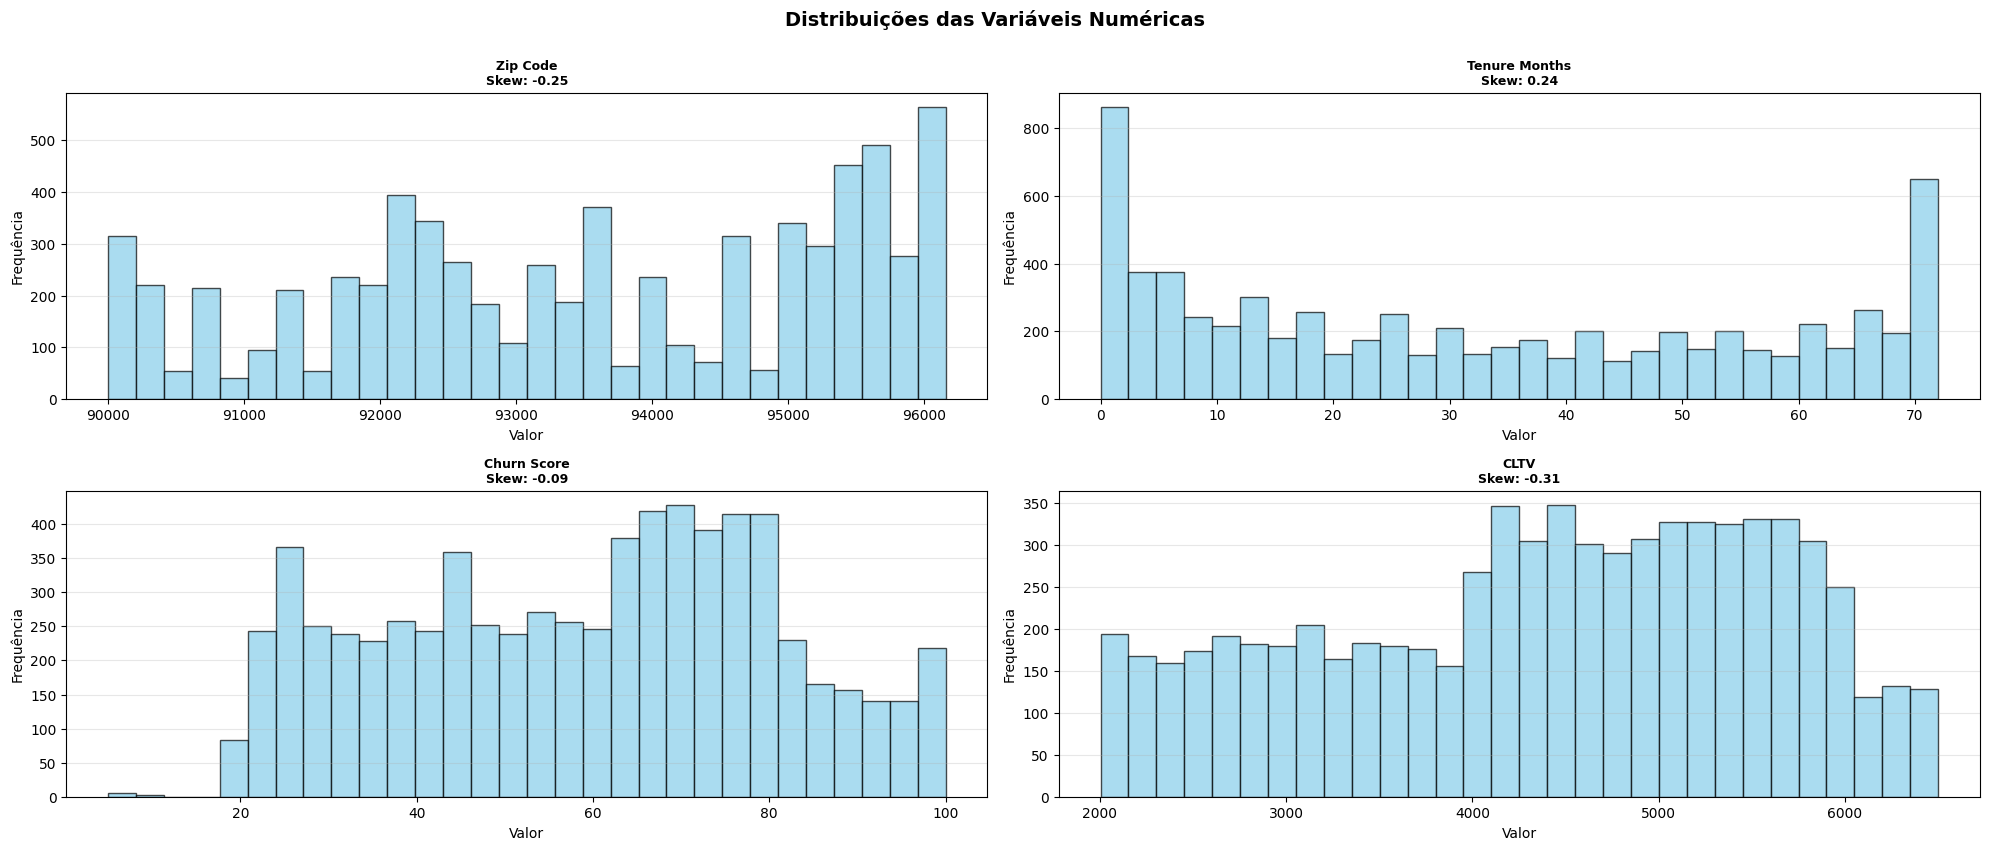

In [13]:

distribution_stats = []
for col in numeric_cols_without_target:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    distribution_stats.append({
        'column': col, 
        'skewness': round(skewness, 2), 
        'kurtosis': round(kurtosis, 2),
        'Interpretação': 'Normal' if abs(skewness) < 0.5 else ('Assimétrica à direita' if skewness > 0 else 'Assimétrica à esquerda')
    })

distribution_stats_df = pd.DataFrame(distribution_stats)
print(distribution_stats_df.to_string(index=False))

#grafico de distribuição usando histogramas para as colunas numéricas, com o valor do skewness no título de cada gráfico
fig, axes = plt.subplots(3, 2, figsize=(20, 12))
axes = axes.ravel()

for i, col in enumerate(numeric_cols_without_target):
    if i < len(axes):
        axes[i].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{col}\nSkew: {df[col].skew():.2f}', fontsize=9, fontweight='bold')
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frequência')
        axes[i].grid(axis='y', alpha=0.3)

# Remover subplots vazios
for i in range(len(numeric_cols_without_target), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Distribuições das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


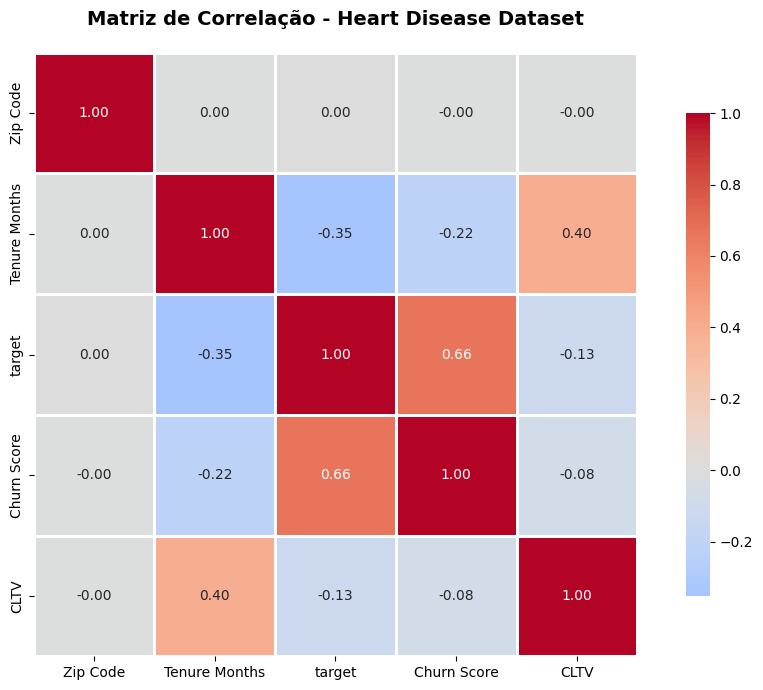

=== CORRELAÇÕES COM A VARIÁVEL TARGET ===

target           1.000000
Churn Score      0.664897
Zip Code         0.003346
CLTV            -0.127463
Tenure Months   -0.352229
Name: target, dtype: float64


In [14]:
numeric_cols_without_count = numeric_cols.drop(['Count'])
numeric_corr = df[numeric_cols_without_count].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Heart Disease Dataset', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("=== CORRELAÇÕES COM A VARIÁVEL TARGET ===\n")
target_corr = numeric_corr['target'].sort_values(ascending=False)
print(target_corr)

### Preparação dos dados

In [15]:
print(missing_values)

                   columns  missing_count  missing_percentage
Churn Reason  Churn Reason           5174               73.46


In [16]:
df_clean = df.copy()
df_clean.head(4)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,target,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783","33,964131","-118,272783",Male,...,Month-to-month,Yes,Mailed check,"53,85","108,15",Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742","34,059281","-118,307420",Female,...,Month-to-month,Yes,Electronic check,"70,7","151,65",Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953","34,048013","-118,293953",Female,...,Month-to-month,Yes,Electronic check,"99,65","820,5",Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709","34,062125","-118,315709",Female,...,Month-to-month,Yes,Electronic check,"104,8","3046,05",Yes,1,84,5003,Moved


In [17]:
df_clean.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'target',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [18]:
df_categorical = df_clean[df_clean.select_dtypes(include=['object']).columns] 
df_categorical.nunique() # para verificar a quantidade de categorias únicas em cada coluna categórica e definir a estratégia de encode


CustomerID           7043
Country                 1
State                   1
City                 1129
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Reason           20
dtype: int64

In [19]:
df_clean['Monthly Charges'] = df_clean['Monthly Charges'].str.replace(',', '.')
df_clean['Monthly Charges'] = df_clean['Monthly Charges'].astype(float)

In [20]:
# Variaveis categoricas nominais ou binarias boas para usar

categorical_cols = ['Gender', 
                    'Partner', 
                    'Dependents', 
                    'Phone Service', 
                    'Multiple Lines', 
                    'Internet Service', 
                    'Online Security', 
                    'Online Backup', 
                    'Device Protection', 
                    'Tech Support', 
                    'Streaming TV', 
                    'Streaming Movies', 
                    'Contract', 
                    'Paperless Billing', 
                    'Payment Method']

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

df_encoded = df_encoded.select_dtypes(include=['number', 'bool'])
df_encoded = df_encoded.drop(columns=['Count', 'Zip Code', 'Churn Score', 'CLTV'])

print(f"Shape após one-hot encoding: {df_encoded.shape}")
df_encoded.columns

Shape após one-hot encoding: (7043, 29)


Index(['Tenure Months', 'Monthly Charges', 'target', 'Gender_Male',
       'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes',
       'Multiple Lines_No phone service', 'Multiple Lines_Yes',
       'Internet Service_Fiber optic', 'Internet Service_No',
       'Online Security_No internet service', 'Online Security_Yes',
       'Online Backup_No internet service', 'Online Backup_Yes',
       'Device Protection_No internet service', 'Device Protection_Yes',
       'Tech Support_No internet service', 'Tech Support_Yes',
       'Streaming TV_No internet service', 'Streaming TV_Yes',
       'Streaming Movies_No internet service', 'Streaming Movies_Yes',
       'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

In [21]:
df_encoded.to_csv('../data/processed/telco_customer_churn_processed.csv', index=False)